# 02b — Fine-tuning view classifier na SYNTETYCZNYM datasecie AFAST (Tydzień 2 — wariant)

**Cel sesji:** ten sam pipeline co `02_finetune_view_classifier.ipynb`, ale na **syntetycznym datasecie weterynaryjnym AFAST** (Marta wygenerowała procedualnie 14.05.2026). Zamiast 6-klasowego FETAL_PLANES_DB (humanoidalne projekcje płodowe — proxy medyczne) trenujemy **4-klasowy klasyfikator okien AFAST u zwierząt**.

**Klasy AFAST** (Abdominal Focused Assessment with Sonography for Trauma — standardowy protokół ratunkowego USG u psów i kotów):
| Kod | Pełna nazwa | Co reprezentuje |
|-----|-------------|------------------|
| CC | Cysto-Colic | okno pęcherz-okrężnica (nadłonowe) |
| DH | Diaphragmatico-Hepatic | okno przeponowo-wątrobowe (subxiphoid) |
| HR | Hepato-Renal | okno wątrobowo-nerkowe (prawe brzuszne) |
| SR | Spleno-Renal | okno śledzionowo-nerkowe (lewe brzuszne) |

**⚠️ Dane są SYNTETYCZNE — nie kliniczne.** Wygenerowane proceduralnie (numpy/PIL + szum Rayleigh + maska sektora głowicy). Cel: **sanity check pipeline'u + uniknięcie klasyfikacji jako AI system wysokiego ryzyka wg AI Act** (POC nie operuje na real medical data). Produkcyjny Vet Eye będzie potem trenowany na real-world veterinary data.

**Dataset:**
- 4 klasy × 1000 obrazów = 4000 total
- Split 80/20: 3200 train (800/klasa) / 800 test (200/klasa) — **idealnie zbalansowane**
- Obrazy PNG 256×256 grayscale, ~126 MB

**Definition of Done:**
- ✅ val (test) accuracy **≥ 0.90** (README sugeruje >0.95 — klasy wizualnie bardzo odróżnialne)
- ✅ confusion matrix PNG zapisana
- ✅ checkpoint na Google Drive

**Co jest INNE vs notebook 02:**
- ✅ `torchvision.ImageFolder` zamiast custom Dataset class + CSV parsing (foldery per klasa to wszystko)
- ✅ Zwykły `DataLoader(shuffle=True)` zamiast `WeightedRandomSampler` (klasy zbalansowane)
- ✅ `Grayscale(num_output_channels=3)` w transformacji (obrazy są grayscale, TinyUSFM oczekuje 3 kanałów)
- ✅ `num_classes=4` zamiast 6
- ✅ Kopia folderu z Drive zamiast unzip ZIP

**Co jest TAKIE SAME jak w 02:**
- TinyUSFM jako backbone (te same wagi, ten sam loading przez clone repo + gdown)
- Augmentacje (Rotate, HFlip, BrightnessContrast)
- Strategia 2-iteracyjna (linear probing → bezpiecznik z odmrożeniem 2 bloków)
- AdamW + CrossEntropyLoss

## 1. Setup: pip install, mount Drive, importy

**Co tu się dzieje:** instalujemy biblioteki ML (te same co w 02 + zachowujemy `timm==0.5.4` jako wymóg TinyUSFM), montujemy Google Drive, ustawiamy seed.

In [1]:
# Instalujemy: timm w wersji 0.5.4 (WYMÓG TinyUSFM - nowsze wersje psują kompatybilność),
# scikit-learn (confusion matrix, classification report), seaborn (ładny heatmap),
# albumentations (augmentacje obrazów - lepsze niż torchvision dla danych medycznych)
!pip install -q timm==0.5.4 scikit-learn seaborn albumentations gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 24.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, sys, json, time, random, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms as T
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie seedów — żeby wyniki były takie same przy każdym uruchomieniu.
# Senior konsultanci to sprawdzą, więc lepiej żeby było reproducible.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Setup datasetu — kopia z Drive na lokalny dysk Colab

W przeciwieństwie do notebooka 02 nie mamy tu ZIP-a — dataset siedzi na Drive jako rozpakowany folder `vet_eye_demo/synthetic_usg_dataset/dataset/` z podfolderami `train/{CC,DH,HR,SR}/` i `test/{CC,DH,HR,SR}/`.

**Co robimy:**
1. Sprawdzamy że folder z datasetem jest na Drive.
2. **Kopiujemy folder rekurencyjnie na lokalny dysk Colab (`/content`)** — dataset jest mały (4000 obrazów, ~126 MB), ale Drive nadal jest wolny przy małych plikach. Lokalna kopia = ~10× szybsze odczyty w treningu.
3. Weryfikujemy strukturę: 4 klasy × 1000 obrazów.

**Jeśli ścieżka na Twoim Drive jest inna** — podmień stałą `DATA_DIR_ON_DRIVE` poniżej.

In [4]:
# ============================================================
# KROK A: gdzie leży dataset na Drive
# ============================================================
# UWAGA: jeśli wrzuciłaś dataset w innej lokalizacji — podmień ścieżkę.
DATA_DIR_ON_DRIVE = '/content/drive/MyDrive/vet_eye_demo/synthetic_usg_dataset/dataset'

assert os.path.exists(DATA_DIR_ON_DRIVE), (
    f'Nie znaleziono folderu datasetu w: {DATA_DIR_ON_DRIVE}\n'
    'Sprawdź gdzie jest: w nowej komórce odpal `!ls "/content/drive/MyDrive/vet_eye_demo/"` '
    'i podmień DATA_DIR_ON_DRIVE powyżej.'
)
assert os.path.exists(os.path.join(DATA_DIR_ON_DRIVE, 'train')), 'Brak podfolderu train/ w datasecie!'
assert os.path.exists(os.path.join(DATA_DIR_ON_DRIVE, 'test')),  'Brak podfolderu test/ w datasecie!'
print(f'OK — dataset znaleziony na Drive: {DATA_DIR_ON_DRIVE}')

# ============================================================
# KROK B: kopia datasetu na lokalny dysk Colab (idempotentne)
# ============================================================
LOCAL_DATA_DIR = '/content/synthetic_usg_dataset'

if not os.path.exists(LOCAL_DATA_DIR):
    print('Kopiuję dataset z Drive na /content... (~3-5 min — 4000 plików x 32kB)')
    shutil.copytree(DATA_DIR_ON_DRIVE, LOCAL_DATA_DIR)
    print('  -> skopiowane')
else:
    print(f'OK — już skopiowane wcześniej, pomijam: {LOCAL_DATA_DIR}')

# ============================================================
# KROK C: weryfikacja struktury
# ============================================================
TRAIN_DIR = os.path.join(LOCAL_DATA_DIR, 'train')
TEST_DIR  = os.path.join(LOCAL_DATA_DIR, 'test')

# Klasy = nazwy podfolderów w train/ (powinny być takie same w test/)
CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES = len(CLASSES)
print(f'\nWykryte klasy ({NUM_CLASSES}): {CLASSES}')

# Sanity check - liczba plików per klasa
print('\nLiczba plików w train/:')
for c in CLASSES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    print(f'  {c}: {n} obrazów')
print('\nLiczba plików w test/:')
for c in CLASSES:
    n = len(os.listdir(os.path.join(TEST_DIR, c)))
    print(f'  {c}: {n} obrazów')

# Foldery na checkpointy i artefakty — ZOSTAJĄ NA DRIVE
CKPT_DIR = '/content/drive/MyDrive/vet-eye-ai-usg-demo/checkpoints/02b_synthetic'
OUT_DIR  = '/content/drive/MyDrive/vet-eye-ai-usg-demo/outputs/02b_synthetic'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
print(f'\nCheckpointy:  {CKPT_DIR}')
print(f'Artefakty:    {OUT_DIR}')

OK — dataset znaleziony na Drive: /content/drive/MyDrive/vet_eye_demo/synthetic_usg_dataset/dataset
Kopiuję dataset z Drive na /content... (~3-5 min — 4000 plików x 32kB)
  -> skopiowane

Wykryte klasy (4): ['CC', 'DH', 'HR', 'SR']

Liczba plików w train/:
  CC: 800 obrazów
  DH: 800 obrazów
  HR: 800 obrazów
  SR: 800 obrazów

Liczba plików w test/:
  CC: 200 obrazów
  DH: 200 obrazów
  HR: 200 obrazów
  SR: 200 obrazów

Checkpointy:  /content/drive/MyDrive/vet-eye-ai-usg-demo/checkpoints/02b_synthetic
Artefakty:    /content/drive/MyDrive/vet-eye-ai-usg-demo/outputs/02b_synthetic


## 3. Dataset + augmentacje (ImageFolder + albumentations)

**Co zmienia się vs notebook 02:**

- W 02 mieliśmy custom `FetalPlanesDataset` z parsowaniem CSV. Tu wystarczy **`torchvision.ImageFolder`** — biblioteka **sama mapuje strukturę folderów na klasy**: `train/CC/img.png` → label 0, `train/DH/img.png` → label 1 itd. (alfabetycznie).
- Obrazy są **grayscale 256×256**, ale TinyUSFM oczekuje **3 kanałów 224×224**. Trick: `Grayscale(num_output_channels=3)` powiela 1 kanał na 3 (R=G=B).
- Augmentacje **takie same jak w 02** (Rotate ±15°, HFlip, BrightnessContrast). Nie używamy VerticalFlip — w USG góra/dół ma znaczenie anatomiczne.

**Drobny trick techniczny:** ImageFolder wymaga callable (funkcji) jako `transform`, ale albumentations zwraca dict. Owijamy w lambdę: `lambda img: train_alb(image=np.array(img))['image']`. Brzmi dziwnie, działa idealnie.

In [5]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentacje albumentations - identyczne jak w 02
train_alb = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0),
    A.Rotate(limit=15, p=0.5, border_mode=0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_alb = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Wrappery - ImageFolder podaje PIL Image, albumentations potrzebuje numpy array.
# Konwersja grayscale -> 3 kanały (powielenie kanału) zachodzi przez .convert('RGB').
def make_transform(alb):
    def _tfm(pil_img):
        # PIL grayscale -> RGB (powiela kanał) -> numpy array (H, W, 3)
        arr = np.array(pil_img.convert('RGB'))
        return alb(image=arr)['image']
    return _tfm

train_ds = ImageFolder(TRAIN_DIR, transform=make_transform(train_alb))
val_ds   = ImageFolder(TEST_DIR,  transform=make_transform(val_alb))

# Sanity check
print(f'train_ds: {len(train_ds)} obrazów, val_ds: {len(val_ds)} obrazów')
print(f'Klasy wykryte przez ImageFolder: {train_ds.classes}')
print(f'Mapowanie class -> idx: {train_ds.class_to_idx}')

# Test - wczytaj pierwszy obraz
x, y = train_ds[0]
print(f'\nPierwszy tensor: shape={tuple(x.shape)}, dtype={x.dtype}, label={y} ({train_ds.classes[y]})')

# Upewnij się, że klasy są takie same w train i val
assert train_ds.classes == val_ds.classes, 'Klasy w train i val nie są te same!'
CLASSES = train_ds.classes  # zaktualizujmy stałą - ImageFolder jest źródłem prawdy

train_ds: 3200 obrazów, val_ds: 800 obrazów
Klasy wykryte przez ImageFolder: ['CC', 'DH', 'HR', 'SR']
Mapowanie class -> idx: {'CC': 0, 'DH': 1, 'HR': 2, 'SR': 3}

Pierwszy tensor: shape=(3, 224, 224), dtype=torch.float32, label=0 (CC)


## 4. DataLoader

**Co zmienia się vs notebook 02:** **bez `WeightedRandomSampler`**. W 02 klasy były niezbalansowane (Other 31%, Fetal femur 6%), więc trzeba było wymuszać równomierne losowanie. Tu mamy **idealny balans (25%/klasa)** — wystarczy zwykły `shuffle=True`.

In [6]:
BATCH_SIZE = 32
NUM_WORKERS = 2  # Colab nie lubi większych wartości

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
print(f'train batches: {len(train_loader)}, val batches: {len(val_loader)}')
# Oczekiwane: train=100 (3200/32), val=25 (800/32)

train batches: 100, val batches: 25


## 5. Model: TinyUSFM (zamrożony backbone) + trening głowy klasyfikacyjnej

**Identyczne jak w notebooku 02 — tylko `num_classes=4` zamiast 6.**

Strategia:
1. Clone repo TinyUSFM + pretrained checkpoint (te same wagi jak w 02).
2. `TinyUSFM(num_classes=4, global_pool=True)` — głowa Linear 192→4 zamiast 192→6.
3. Zamrożenie wszystkiego oprócz `model.head` + `model.fc_norm` (linear probing).
4. Trenowanych: ~1028 wag = 192×4 + 4 (head) + 2×192 (fc_norm).

📚 **Ważna uwaga:** TinyUSFM był pretrained na **prawdziwych USG**. Tu trenujemy go na **syntetycznych** obrazach (procedualnie generowane geometryczne struktury + szum speckle). Transfer learning może być **słabszy** niż dla FETAL_PLANES_DB, bo featury syntetyczne nie odpowiadają dokładnie temu, na co TinyUSFM patrzy. Ale syntetyczne obrazy zachowują cechy USG (Rayleigh speckle, gamma correction, maska sektora) — więc backbone powinien je rozpoznać jako "USG-podobne".

In [7]:
# ============================================================
# KROK A: Sklonowanie repo TinyUSFM + pobranie pretrained checkpointu
# ============================================================
TINYUSFM_DIR = '/content/TinyUSFM'
CKPT_TINYUSFM = '/content/checkpoints/TinyUSFM.pth'
GDRIVE_ID = '1P_wDuU-StALLJEBaymioaYu52CScW-l-'

if not os.path.exists(TINYUSFM_DIR):
    !git clone -q https://github.com/MacDunno/TinyUSFM.git $TINYUSFM_DIR
    print('OK - sklonowano repo TinyUSFM')
else:
    print(f'OK - repo już jest: {TINYUSFM_DIR}')

os.makedirs('/content/checkpoints', exist_ok=True)
if not os.path.exists(CKPT_TINYUSFM):
    !gdown $GDRIVE_ID -O $CKPT_TINYUSFM
    print('OK - pobrano checkpoint TinyUSFM')
else:
    size_mb = os.path.getsize(CKPT_TINYUSFM) / (1024**2)
    print(f'OK - checkpoint już jest: {CKPT_TINYUSFM} ({size_mb:.0f} MB)')

import timm
assert timm.__version__ == '0.5.4', (
    f'TinyUSFM wymaga timm==0.5.4, masz {timm.__version__}.\n'
    'Restart runtime + Run all.'
)
print(f'OK - timm w prawidłowej wersji: {timm.__version__}')

sys.path.insert(0, TINYUSFM_DIR)
from model.tinyusfm import TinyUSFM
print('OK - import TinyUSFM gotowy')

OK - sklonowano repo TinyUSFM
Downloading...
From: https://drive.google.com/uc?id=1P_wDuU-StALLJEBaymioaYu52CScW-l-
To: /content/checkpoints/TinyUSFM.pth
100% 22.1M/22.1M [00:00<00:00, 47.2MB/s]
OK - pobrano checkpoint TinyUSFM
OK - timm w prawidłowej wersji: 0.5.4
OK - import TinyUSFM gotowy


In [8]:
# ============================================================
# KROK B: Model z głową 4-klasową, ładowanie wag, zamrożenie backbone
# ============================================================

# Model dla 4 klas AFAST (zamiast 6 klas FETAL_PLANES jak w 02)
model = TinyUSFM(num_classes=NUM_CLASSES, global_pool=True).to(DEVICE)

# Ładujemy pretrained wagi
ckpt = torch.load(CKPT_TINYUSFM, map_location=DEVICE, weights_only=True)
load_info = model.load_state_dict(ckpt, strict=False)
print(f'Missing keys (głowa - inicjalizowana losowo, będzie trenowana): {load_info.missing_keys}')
print(f'Unexpected keys (ignorowane): {load_info.unexpected_keys}')

# Zamrażamy WSZYSTKO oprócz głowy + fc_norm (linear probing - jak w 02 Iteracja 1)
for name, p in model.named_parameters():
    if 'head' in name or 'fc_norm' in name:
        p.requires_grad = True
    else:
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'\nTrainable params: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)')
print(f'Trenowane warstwy: model.head (Linear 192->4 klas) + model.fc_norm (LayerNorm 192)')
print('Backbone (cała reszta - pretrained na USG) - ZAMROŻONY')

Missing keys (głowa - inicjalizowana losowo, będzie trenowana): ['model.head.weight', 'model.head.bias', 'model.fc_norm.weight', 'model.fc_norm.bias']
Unexpected keys (ignorowane): ['model.norm.weight', 'model.norm.bias']

Trainable params: 1,156 / 5,525,188 (0.021%)
Trenowane warstwy: model.head (Linear 192->4 klas) + model.fc_norm (LayerNorm 192)
Backbone (cała reszta - pretrained na USG) - ZAMROŻONY


## 6. Training loop

**Identyczny jak w notebooku 02 — strategia 2-iteracyjna.** Startujemy z `EPOCHS=5, LR=1e-3` (linear probing). Jeśli nie dobijemy do `val_acc=0.90` → bezpiecznik z odmrożeniem 2 bloków (komórki na końcu).

**README datasetu sugeruje, że dla prostych klasyfikatorów na tym zbiorze osiągalne jest >95% accuracy** — bo klasy są wizualnie bardzo odróżnialne (różne struktury anatomiczne na każdym oknie). Czyli **już linear probing powinien wystarczyć** — jeśli nie, znaczy że TinyUSFM słabo transfer-uje na syntetykę (interesujące dla pracy).

Czas spodziewany na T4: ~1 min na epokę (dataset jest 3× mniejszy niż FETAL_PLANES). 5 epok = ~5-7 min.

In [10]:
# Sanity check - znajdź uszkodzone (0-bajtowe lub truncated) pliki
from PIL import Image
import glob

bad_files = []
total = 0
for split in ['train', 'test']:
    for cls in CLASSES:
        cls_dir = os.path.join(LOCAL_DATA_DIR, split, cls)
        for path in glob.glob(os.path.join(cls_dir, '*.png')):
            total += 1
            try:
                if os.path.getsize(path) == 0:
                    bad_files.append((path, 'zero-byte'))
                    continue
                Image.open(path).verify()  # sprawdza nagłówek bez pełnego wczytania
            except Exception as e:
                bad_files.append((path, str(e)[:60]))

print(f'Sprawdzono: {total} plików')
print(f'Uszkodzonych: {len(bad_files)}')
if bad_files:
    print('\nPierwsze 10:')
    for path, reason in bad_files[:10]:
        rel = os.path.relpath(path, LOCAL_DATA_DIR)
        print(f'  {rel}  -> {reason}')

Sprawdzono: 4000 plików
Uszkodzonych: 1

Pierwsze 10:
  train/SR/SR_0089.png  -> Truncated File Read


In [11]:
# Przekopiowanie uszkodzonych plików z Drive
import shutil
fixed = 0
for bad_path, _ in bad_files:
    rel = os.path.relpath(bad_path, LOCAL_DATA_DIR)  # np. 'train/CC/CC_0123.png'
    src = os.path.join(DATA_DIR_ON_DRIVE, rel)
    if os.path.exists(src) and os.path.getsize(src) > 0:
        shutil.copy(src, bad_path)
        fixed += 1
    else:
        print(f'UWAGA - na Drive też uszkodzony: {rel}')

print(f'\nPrzekopiowano: {fixed}/{len(bad_files)}')

# Walidacja - sprawdź jeszcze raz
still_bad = []
for path, _ in bad_files:
    try:
        Image.open(path).verify()
    except:
        still_bad.append(path)
print(f'Wciąż uszkodzone: {len(still_bad)}')


Przekopiowano: 1/1
Wciąż uszkodzone: 1


In [12]:
# Znajdź wszystkie uszkodzone (0-bajtowe lub truncated) PNG-i i wywal je z lokalnego datasetu
from PIL import Image
import glob

bad_files = []
total = 0
for split in ['train', 'test']:
    for cls in CLASSES:
        cls_dir = os.path.join(LOCAL_DATA_DIR, split, cls)
        for path in glob.glob(os.path.join(cls_dir, '*.png')):
            total += 1
            try:
                if os.path.getsize(path) == 0:
                    bad_files.append((path, 'zero-byte'))
                    continue
                Image.open(path).verify()
            except Exception as e:
                bad_files.append((path, str(e)[:60]))

print(f'Sprawdzono: {total} plików')
print(f'Uszkodzonych: {len(bad_files)}')

# Pokaż pierwsze 20 - dla orientacji jak są rozłożone klasami
if bad_files:
    print('\nPierwsze 20:')
    for path, reason in bad_files[:20]:
        rel = os.path.relpath(path, LOCAL_DATA_DIR)
        print(f'  {rel}  -> {reason}')

    # WYWAL uszkodzone z LOCAL_DATA_DIR (NIE z Drive - oryginał zostaje na potem)
    for path, _ in bad_files:
        os.remove(path)
    print(f'\nWywalono {len(bad_files)} uszkodzonych plików z lokalnej kopii.')

# Sanity check po
print('\nLiczba plików per klasa po wyczyszczeniu:')
for split in ['train', 'test']:
    print(f'  {split}/')
    for cls in CLASSES:
        n = len(os.listdir(os.path.join(LOCAL_DATA_DIR, split, cls)))
        print(f'    {cls}: {n}')

Sprawdzono: 4000 plików
Uszkodzonych: 1

Pierwsze 20:
  train/SR/SR_0089.png  -> Truncated File Read

Wywalono 1 uszkodzonych plików z lokalnej kopii.

Liczba plików per klasa po wyczyszczeniu:
  train/
    CC: 800
    DH: 800
    HR: 800
    SR: 799
  test/
    CC: 200
    DH: 200
    HR: 200
    SR: 200


In [13]:
# Odbuduj dataset i DataLoader po wykasowaniu uszkodzonych plików
train_ds = ImageFolder(TRAIN_DIR, transform=make_transform(train_alb))
val_ds   = ImageFolder(TEST_DIR,  transform=make_transform(val_alb))

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'train_ds: {len(train_ds)} obrazów, val_ds: {len(val_ds)} obrazów')
print(f'train batches: {len(train_loader)}, val batches: {len(val_loader)}')

# Bezpiecznik PIL na wszelki wypadek (gdyby coś nam się jeszcze prześlizgnęło)
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

train_ds: 3199 obrazów, val_ds: 800 obrazów
train batches: 99, val batches: 25


In [16]:
EPOCHS = 8
LR = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, losses = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            losses.append(loss.item())
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return np.mean(losses), accuracy_score(all_labels, all_preds), all_preds, all_labels

best_val_acc = 0.0
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        if i % 25 == 0:
            print(f'  [Epoch {epoch} | batch {i}/{len(train_loader)}] loss={loss.item():.4f}')
    train_loss = np.mean(epoch_losses)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    elapsed = (time.time() - start) / 60
    print(f'Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | time={elapsed:.1f} min')

    ckpt_path = os.path.join(CKPT_DIR, f'epoch_{epoch:02d}_acc_{val_acc:.4f}.pt')
    torch.save({
        'epoch': epoch, 'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'val_acc': val_acc, 'classes': CLASSES,
    }, ckpt_path)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'val_acc': val_acc, 'classes': CLASSES,
        }, os.path.join(CKPT_DIR, 'best.pt'))
        print(f'  ↑ Nowy najlepszy model (val_acc={val_acc:.4f}) → best.pt')

print(f'\nKoniec treningu. Best val_acc: {best_val_acc:.4f}')
print(f'DoD spełnione (val_acc >= 0.90): {"✅ TAK" if best_val_acc >= 0.90 else "❌ NIE — uruchom komórkę z bezpiecznikiem"}')

  [Epoch 1 | batch 0/99] loss=0.9681
  [Epoch 1 | batch 25/99] loss=0.7178
  [Epoch 1 | batch 50/99] loss=0.6063
  [Epoch 1 | batch 75/99] loss=0.2883
Epoch 1/8 | train_loss=0.6127 | val_loss=0.2286 | val_acc=0.9300 | time=0.3 min
  ↑ Nowy najlepszy model (val_acc=0.9300) → best.pt
  [Epoch 2 | batch 0/99] loss=0.1592
  [Epoch 2 | batch 25/99] loss=0.1020
  [Epoch 2 | batch 50/99] loss=0.0880
  [Epoch 2 | batch 75/99] loss=0.0412
Epoch 2/8 | train_loss=0.1105 | val_loss=0.0784 | val_acc=0.9675 | time=0.5 min
  ↑ Nowy najlepszy model (val_acc=0.9675) → best.pt
  [Epoch 3 | batch 0/99] loss=0.0266
  [Epoch 3 | batch 25/99] loss=0.0174
  [Epoch 3 | batch 50/99] loss=0.0166
  [Epoch 3 | batch 75/99] loss=0.0251
Epoch 3/8 | train_loss=0.0414 | val_loss=0.0302 | val_acc=0.9875 | time=0.8 min
  ↑ Nowy najlepszy model (val_acc=0.9875) → best.pt
  [Epoch 4 | batch 0/99] loss=0.0593
  [Epoch 4 | batch 25/99] loss=0.0094
  [Epoch 4 | batch 50/99] loss=0.1664
  [Epoch 4 | batch 75/99] loss=0.0193


## 7. Walidacja: classification report + confusion matrix PNG

In [17]:
best_ckpt = torch.load(os.path.join(CKPT_DIR, 'best.pt'), map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state'])
print(f'Załadowano best.pt (epoch={best_ckpt["epoch"]}, val_acc={best_ckpt["val_acc"]:.4f})')

_, val_acc, preds, labels = evaluate(model, val_loader)
print(f'\nFinal val accuracy: {val_acc:.4f}\n')
print(classification_report(labels, preds, target_names=CLASSES, digits=4))

report_dict = classification_report(labels, preds, target_names=CLASSES, digits=4, output_dict=True)
with open(os.path.join(OUT_DIR, 'classification_report.json'), 'w') as f:
    json.dump({'val_acc': val_acc, 'report': report_dict, 'history': history}, f, indent=2)
print(f'Raport zapisany: {OUT_DIR}/classification_report.json')

Załadowano best.pt (epoch=8, val_acc=0.9975)

Final val accuracy: 0.9975

              precision    recall  f1-score   support

          CC     1.0000    1.0000    1.0000       200
          DH     1.0000    1.0000    1.0000       200
          HR     0.9950    0.9950    0.9950       200
          SR     0.9950    0.9950    0.9950       200

    accuracy                         0.9975       800
   macro avg     0.9975    0.9975    0.9975       800
weighted avg     0.9975    0.9975    0.9975       800

Raport zapisany: /content/drive/MyDrive/vet-eye-ai-usg-demo/outputs/02b_synthetic/classification_report.json


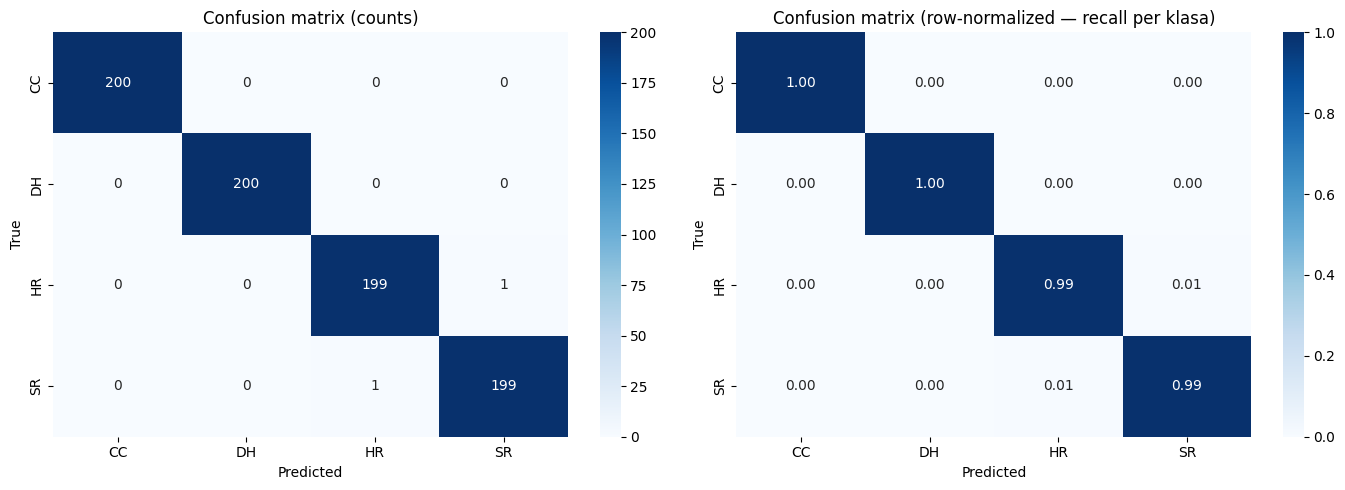

Zapisano: /content/drive/MyDrive/vet-eye-ai-usg-demo/outputs/02b_synthetic/confusion_matrix.png


In [18]:
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion matrix (row-normalized — recall per klasa)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
cm_path = os.path.join(OUT_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Zapisano: {cm_path}')

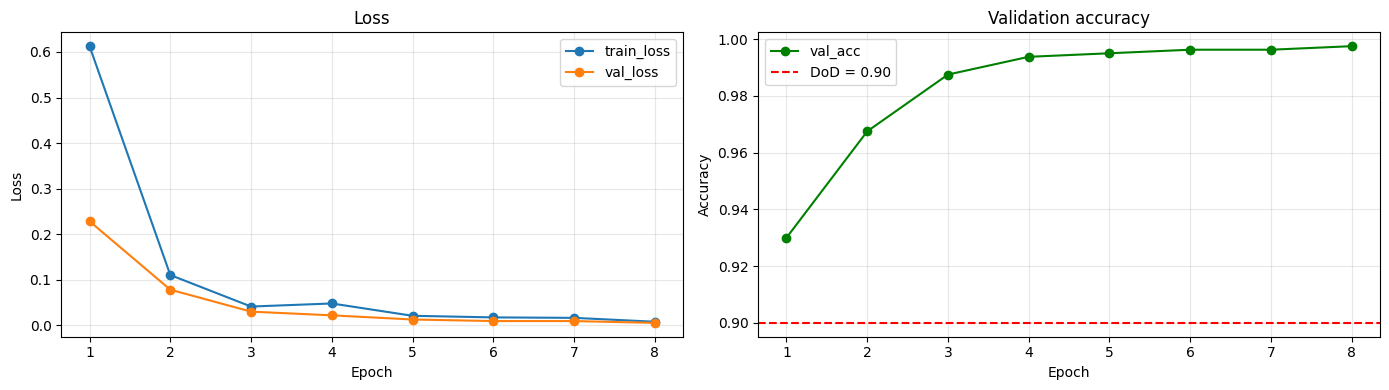

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_x = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_x, history['train_loss'], label='train_loss', marker='o')
axes[0].plot(epochs_x, history['val_loss'], label='val_loss', marker='o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')

axes[1].plot(epochs_x, history['val_acc'], label='val_acc', marker='o', color='green')
axes[1].axhline(0.90, color='red', linestyle='--', label='DoD = 0.90')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Validation accuracy')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. (Opcjonalna) Bezpiecznik — odmrożenie 2 ostatnich bloków backbone

**Jeśli linear probing dał `val_acc < 0.90`** — odpalasz tę komórkę, potem wracasz do komórki 15 i odpalasz trening ponownie (z `EPOCHS=8`, `LR=1e-4`).

Logika identyczna jak w notebooku 02 — odmrażamy `model.blocks.10` + `model.blocks.11` (+ głowę która już była odmrożona).

In [15]:
# BEZPIECZNIK: Odmrożenie 2 ostatnich bloków backbone TinyUSFM
trainable_patterns = [
    'model.head',
    'model.fc_norm',
    'model.blocks.10.',
    'model.blocks.11.',
]

for name, p in model.named_parameters():
    if any(pat in name for pat in trainable_patterns):
        p.requires_grad = True
    else:
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Po odmrożeniu: trainable={trainable:,} / {total:,} ({100*trainable/total:.2f}%)')
print('Trenowane: head + fc_norm + blocks[10,11]')

# NASTĘPNY KROK: wróć do komórki 15, zmień EPOCHS=8 i LR=1e-4, odpal komórkę 15 ponownie

Po odmrożeniu: trainable=890,884 / 5,525,188 (16.12%)
Trenowane: head + fc_norm + blocks[10,11]


---

## Co dalej

**Po wykonaniu tego notebooka:**
1. Pobierz z Drive 3 artefakty (`classification_report.json`, `confusion_matrix.png`, `learning_curves.png`)
2. Commit do repo `vet-eye-ai-usg-demo` jako:
   ```
   notebooks/02b_finetune_synthetic_usg.ipynb
   outputs/02b_synthetic/classification_report.json
   outputs/02b_synthetic/confusion_matrix.png
   outputs/02b_synthetic/learning_curves.png
   ```

**Dla pracy końcowej:**
- Tabela porównawcza 02 (FETAL_PLANES, 6 klas humanoid) vs 02b (synthetic AFAST, 4 klasy vet) — pokazuje **zdolność pipeline'u** do działania na różnych zbiorach.
- W sekcji **"Zgodność regulacyjna"** — argument: POC demo trenowany na danych syntetycznych = nie jest "AI system wysokiego ryzyka" wg AI Act Art. 6 + Aneks III pkt 5b. Produkcyjny Vet Eye będzie potem fine-tunowany na real veterinary data wewnątrz firmy.

**Tydzień 3 (18–24.05):**
- Quality head (heurystyczny)
- Scripted instructions (mapa klasa → instrukcja tekstowa)
- Pełen pipeline klip → klasa + jakość + instrukcja